In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
import shap
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
# 2. LOAD DATASET

df = pd.read_csv('C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\star_classification1.csv')
print(df.head())

         obj_ID       alpha      delta         u         g         r  \
0  1.240000e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.240000e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.240000e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.240000e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.240000e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.540000e+18   
1  21.16812  21.61427    4518       301        5       119  1.180000e+19   
2  19.34857  18.94827    3606       301        2       120  5.150000e+18   
3  20.50454  19.25010    4192       301        3       214  1.030000e+19   
4  15.97711  15.54461    8102       301        3       137  6.890000e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354       171  
1  GALAXY  0.77913

In [4]:
# -----------------------------------------------------
# 3. DATA PREPROCESSING
# -----------------------------------------------------

if 'obj_ID' in df.columns:
    df = df.drop(['obj_ID'], axis=1)

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# -----------------------------------------------------
# 4. HANDLE IMBALANCE (OPTIONAL)
# -----------------------------------------------------

# Comment this if training becomes slow
# sm = SMOTE(random_state=42)
# X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train)

In [5]:
# -----------------------------------------------------
# 5. MODEL TRAINING (OPTIMIZED)
# -----------------------------------------------------

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)
xgb.fit(X_train_scaled, y_train)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
# -----------------------------------------------------
# 6. EVALUATION
# -----------------------------------------------------

print("Random Forest Results:")
print(classification_report(y_test, rf.predict(X_test_scaled)))

print("XGBoost Results:")
print(classification_report(y_test, xgb.predict(X_test_scaled)))


print("\nDecision Tree Results:")
y_pred_dt = dt.predict(X_test_scaled)
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nLogistic Regression Results:")
y_pred_lr = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11860
           1       0.97      0.93      0.95      3797
           2       0.99      1.00      1.00      4343

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

XGBoost Results:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11860
           1       0.96      0.93      0.95      3797
           2       0.99      1.00      0.99      4343

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000


Decision Tree Results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     11860
           1       0.91      0.91      0.91      3797
           


Accuracy Comparison:
Random Forest: 0.97885
XGBoost: 0.9768
Decision Tree: 0.96395
Logistic Regression: 0.955


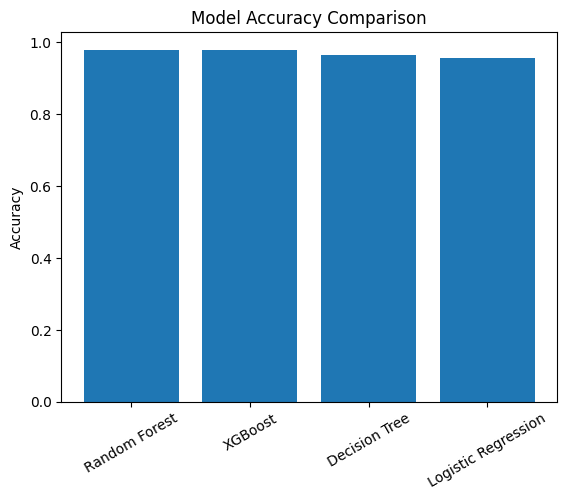

In [7]:
# -----------------------------------------------------
# MODEL ACCURACY COMPARISON
# -----------------------------------------------------

accuracy_scores = {
    "Random Forest": accuracy_score(y_test, rf.predict(X_test_scaled)),
    "XGBoost": accuracy_score(y_test, xgb.predict(X_test_scaled)),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr)
}

print("\nAccuracy Comparison:")
for model, score in accuracy_scores.items():
    print(f"{model}: {score}")

plt.figure()
plt.bar(accuracy_scores.keys(), accuracy_scores.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

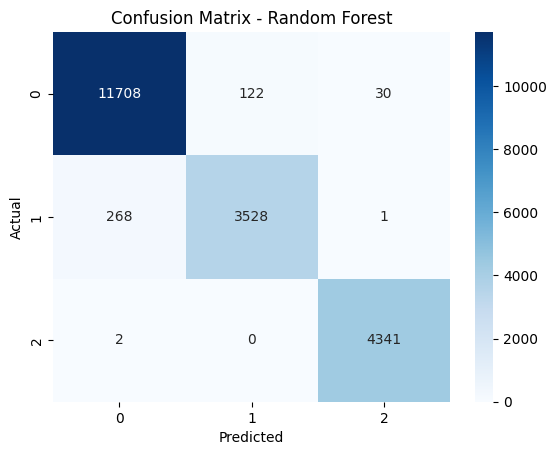

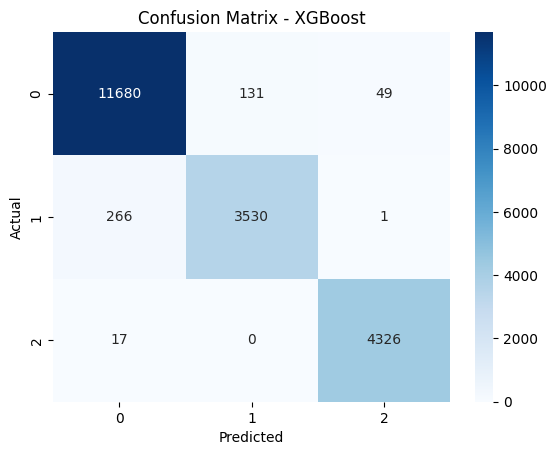

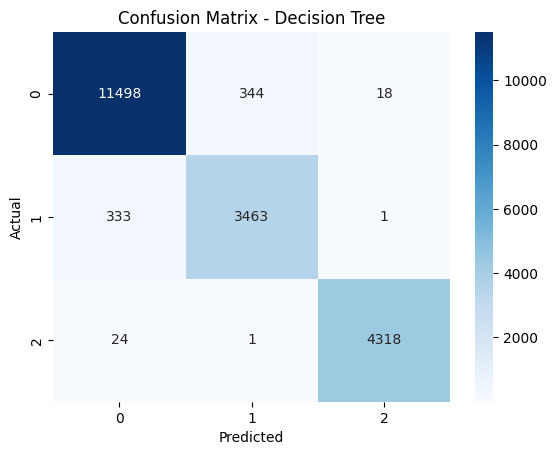

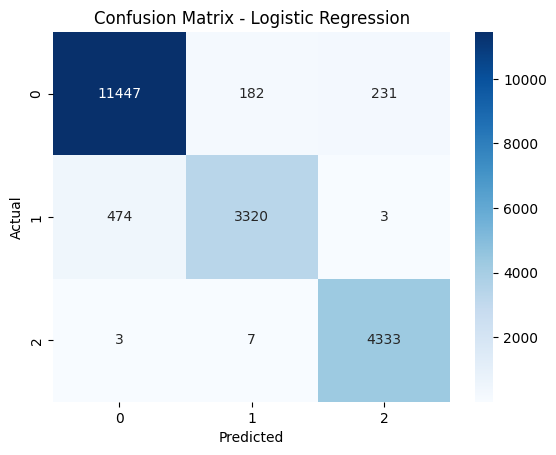

In [9]:
#CONFUSION MATRIX
models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "Decision Tree": dt,
    "Logistic Regression": lr
}

for name, model in models.items():
    plt.figure()
    sns.heatmap(
        confusion_matrix(y_test, model.predict(X_test_scaled)),
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

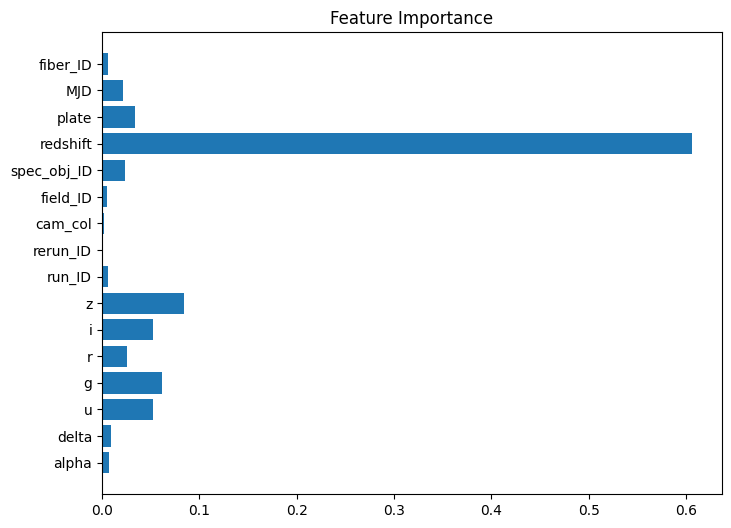

In [10]:
# -----------------------------------------------------
# 7. FEATURE IMPORTANCE
# -----------------------------------------------------

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

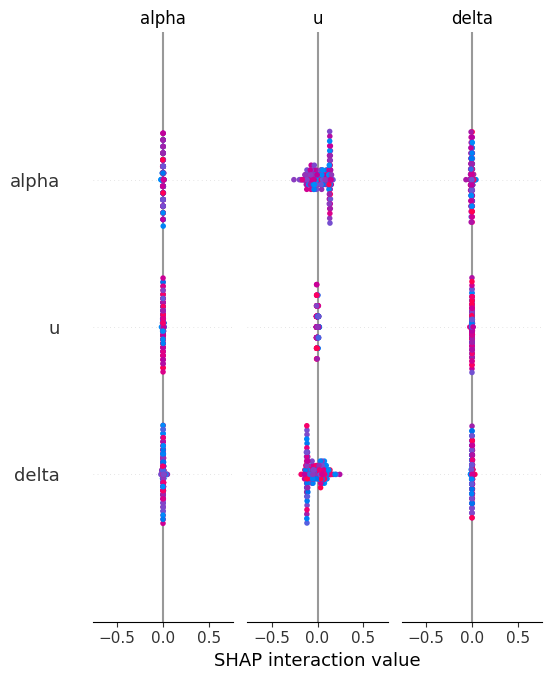

In [11]:
# -----------------------------------------------------
# 8. EXPLAINABILITY (FAST SHAP)
# -----------------------------------------------------

# Use small samples to avoid slow computation
X_sample = X_test_scaled[:200]
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, feature_names=features)


In [15]:
# -----------------------------------------------------
# 9. SAVE MODEL
# -----------------------------------------------------

joblib.dump(rf, 'stellar_rf_model.pkl')
joblib.dump(xgb, 'stellar_xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [12]:
def predict_object(input_data):
    input_scaled = scaler.transform([input_data])
    prediction = rf.predict(input_scaled)
    return le.inverse_transform(prediction)


In [13]:
# 11. EDUCATIONAL OUTPUT FUNCTION
def get_object_details(prediction_class):
    details = {
        'STAR': 'A star is a luminous sphere of plasma held together by gravity. It produces energy through nuclear fusion.',
        'GALAXY': 'A galaxy is a massive system of stars, stellar remnants, gas, dust, and dark matter, bound together by gravity.',
        'QSO': 'Quasar (QSO) is a very energetic and distant active galactic nucleus, powered by a supermassive black hole.'
    }
    return details.get(prediction_class, 'No details available')


In [14]:
# -----------------------------------------------------
# 10. PREDICTION FUNCTION (CORRECT PIPELINE)
# -----------------------------------------------------

def predict_object(input_data):
    input_scaled = scaler.transform([input_data])
    prediction = rf.predict(input_scaled)
    return le.inverse_transform(prediction)


In [15]:
# -----------------------------------------------------
# 11. KNOWLEDGE ENGINE (ADVANCED FEATURE)
# -----------------------------------------------------

def get_object_details(prediction_class):
    details = {
        'STAR': "A star is a massive luminous sphere of plasma that generates energy through nuclear fusion.",
        'GALAXY': "A galaxy is a huge system containing billions of stars, gas, dust, and dark matter.",
        'QSO': "A quasar is an extremely bright and distant object powered by a supermassive black hole."
    }
    return details.get(prediction_class, "No details available")


In [16]:
# -----------------------------------------------------
# 12. CNN MODEL (IMAGE CLASSIFICATION - FUTURE)
# -----------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("CNN ready (train when image dataset is available)")

c:\MSc.FY Projects\Stellar Object Prediction\objenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN ready (train when image dataset is available)


In [21]:
# -----------------------------------------------------
# 13. EXAMPLE USAGE (FINAL FIXED)
# -----------------------------------------------------

example_input = X.iloc[0]   # RAW data (important!)

predicted_class = predict_object(example_input)[0]
details = get_object_details(predicted_class)

print(f"Predicted Class: {predicted_class}")
print(f"Details: {details}")

Predicted Class: GALAXY
Details: A galaxy is a huge system containing billions of stars, gas, dust, and dark matter.


c:\MSc.FY Projects\Stellar Object Prediction\objenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
# -----------------------------------------------------
# 14. READY FOR DEPLOYMENT
# -----------------------------------------------------

print("\nProject Ready: Model + Explainability + Knowledge Engine + Deployment Support")



Project Ready: Model + Explainability + Knowledge Engine + Deployment Support


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# Load your dataset
df = pd.read_csv(r"C:\MSc.FY Projects\Stellar Object Prediction\sdss_data\star_classification1.csv")  # replace with your dataset

# Create LabelEncoder
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])  # target column

# Save it as .pkl
joblib.dump(le, "label_encoder.pkl")
print("✅ LabelEncoder saved as label_encoder.pkl")


✅ LabelEncoder saved as label_encoder.pkl
